In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import japanize_matplotlib

In [2]:
# -------------------------
# パラメータ設定
# -------------------------
x = np.linspace(-5, 5, 1000)
dx = x[1] - x[0]

# 2つのガウス分布（意図的に少し重なるように設定）
mu1, sig1, amp1 = -0.5, 0.6, 1.0   # ガウス1: 中心, 幅, 強度
mu2, sig2, amp2 =  0.5, 0.6, 0.9   # ガウス2: 中心, 幅, 強度

g1 = amp1 * np.exp(-0.5 * ((x - mu1) / sig1) ** 2)
g2 = amp2 * np.exp(-0.5 * ((x - mu2) / sig2) ** 2)
y  = g1 + g2   # 合成波形（観測されるシグナル）


In [3]:
# -------------------------
# 2次微分（数値微分）
# -------------------------
# np.gradient を2回かける（中央差分、端は1次精度）
dy  = np.gradient(y, dx)
d2y = np.gradient(dy, dx)

In [4]:
# -------------------------
# ピーク検出
# -------------------------
# 合成波形のピーク
from scipy.signal import find_peaks
peaks_sum, _ = find_peaks(y, prominence=0.05)

# 2次微分の極小（= 元信号のピーク）：-d2y の極大を探す
peaks_d2, _ = find_peaks(-d2y, prominence=0.005)

print("=" * 50)
print("合成波形のピーク数:  ", len(peaks_sum))
print("  位置:", [f"{x[i]:.3f}" for i in peaks_sum])
print()
print("2次微分の極小数（= 隠れたピーク）:", len(peaks_d2))
print("  位置:", [f"{x[i]:.3f}" for i in peaks_d2])
print("=" * 50)

合成波形のピーク数:   1
  位置: ['-0.085']

2次微分の極小数（= 隠れたピーク）: 2
  位置: ['-0.465', '0.445']


C:\Users\LE_20210215\AppData\Local\Temp\ipykernel_29852\3776368536.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


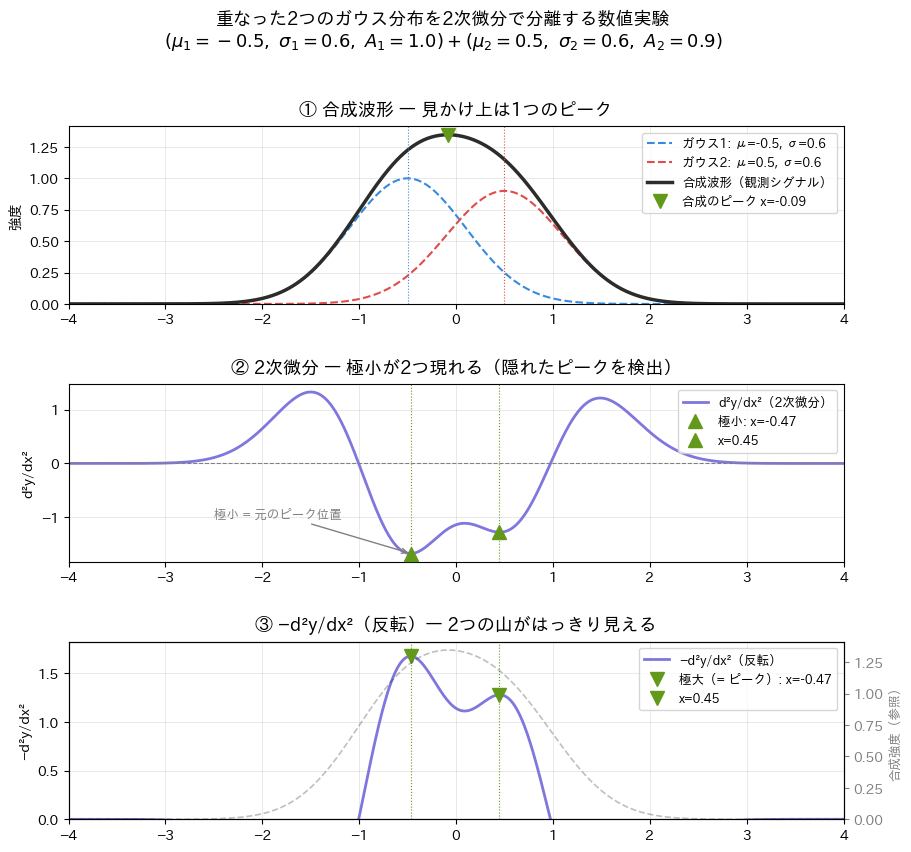

画像を保存しました: gaussian_overlap_demo.png


In [24]:
# プロット
# -------------------------
fig = plt.figure(figsize=(10, 9))
gs = gridspec.GridSpec(3, 1, hspace=0.45)

colors = {
    "g1":   "#378ADD",
    "g2":   "#E24B4A",
    "sum":  "#2C2C2A",
    "d2":   "#7F77DD",
    "peak": "#63991B",
}

# --- (1) 個別ガウスと合成波形 ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(x, g1, color=colors["g1"],  lw=1.5, ls="--", label=f"ガウス1: μ={mu1}, σ={sig1}")
ax1.plot(x, g2, color=colors["g2"],  lw=1.5, ls="--", label=f"ガウス2: μ={mu2}, σ={sig2}")
ax1.plot(x, y,  color=colors["sum"], lw=2.5, label="合成波形（観測シグナル）")
ax1.axvline(mu1, color=colors["g1"], lw=0.8, ls=":")
ax1.axvline(mu2, color=colors["g2"], lw=0.8, ls=":")

# 合成波形のピークにマーカー
for i in peaks_sum:
    ax1.plot(x[i], y[i], "v", color=colors["peak"], ms=10, zorder=5,
             label=f"合成のピーク x={x[i]:.2f}" if i == peaks_sum[0] else "")

ax1.set_title("① 合成波形 — 見かけ上は1つのピーク", fontsize=13, pad=8)
ax1.set_ylabel("強度")
ax1.legend(fontsize=9, loc="upper right")
ax1.set_xlim(-4, 4)
ax1.set_ylim(bottom=0)
ax1.grid(True, lw=0.4, alpha=0.5)

# --- (2) 2次微分 ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(x, d2y, color=colors["d2"], lw=2, label="d²y/dx²（2次微分）")
ax2.axhline(0, color="gray", lw=0.8, ls="--")

# 2次微分の極小（元のピーク位置）
for i in peaks_d2:
    ax2.plot(x[i], d2y[i], "^", color=colors["peak"], ms=10, zorder=5,
             label=f"極小: x={x[i]:.2f}" if i == peaks_d2[0] else f"x={x[i]:.2f}")
    ax2.axvline(x[i], color=colors["peak"], lw=0.8, ls=":")

ax2.set_title("② 2次微分 — 極小が2つ現れる（隠れたピークを検出）", fontsize=13, pad=8)
ax2.set_ylabel("d²y/dx²")
ax2.legend(fontsize=9, loc="upper right")
ax2.set_xlim(-4, 4)
ax2.grid(True, lw=0.4, alpha=0.5)

# 極小の説明テキスト
ax2.annotate("極小 = 元のピーク位置", xy=(x[peaks_d2[0]], d2y[peaks_d2[0]]),
             xytext=(-2.5, d2y.min() * 0.6),
             arrowprops=dict(arrowstyle="->", color="gray", lw=1),
             fontsize=9, color="gray")

# --- (3) -d2y（反転）で視覚的にわかりやすく ---
ax3 = fig.add_subplot(gs[2])
ax3.plot(x, -d2y, color=colors["d2"], lw=2, label="−d²y/dx²（反転）")
ax3.axhline(0, color="gray", lw=0.8, ls="--")

for i in peaks_d2:
    ax3.plot(x[i], -d2y[i], "v", color=colors["peak"], ms=10, zorder=5,
             label=f"極大（= ピーク）: x={x[i]:.2f}" if i == peaks_d2[0] else f"x={x[i]:.2f}")
    ax3.axvline(x[i], color=colors["peak"], lw=0.8, ls=":")

# 参照用に合成波形を薄く重ねる
ax3_twin = ax3.twinx()
ax3_twin.plot(x, y, color=colors["sum"], lw=1.2, ls="--", alpha=0.3, label="合成波形（参照）")
ax3_twin.set_ylabel("合成強度（参照）", fontsize=9, color="gray")
ax3_twin.tick_params(colors="gray")
ax3_twin.set_ylim(bottom=0)

ax3.set_title("③ −d²y/dx²（反転）— 2つの山がはっきり見える", fontsize=13, pad=8)
ax3.set_ylabel("−d²y/dx²")
ax3.legend(fontsize=9, loc="upper right")
ax3.set_xlim(-4, 4)
ax3.set_ylim(bottom=0)
ax3.grid(True, lw=0.4, alpha=0.5)

fig.suptitle(
    "重なった2つのガウス分布を2次微分で分離する数値実験\n"
    f"$(\\mu_1={mu1},\\ \\sigma_1={sig1},\\ A_1={amp1})"
    f" +(\\mu_2={mu2},\\ \\sigma_2={sig2},\\ A_2={amp2})$",
    fontsize=13, y=1.01
)

plt.tight_layout()
plt.savefig("./test.png", dpi=150, bbox_inches="tight")
plt.show()
print("画像を保存しました: gaussian_overlap_demo.png")